# Princing e Descontos em Eventos: Uma Análise de Dados para Apoio à Decisão Comercial

# Introdução

Este trabalho tem como objetivo analisar os dados de vendas de stands do evento Exagerado (meu estágio), com foco em entender os principais fatores que impactam a receita total e o atingimento da meta comercial estabelecida para o evento do RJ.

A receita de vendas de stands depende fundamentalmente de três fatores: o preço por metro quadrado, a área vendida e os descontos condedidos nas negociações, para o evento do Rio, é adicionado também, vendas comissionadas, essas que, serão discutidas ao longo do notebook. Dessa forma, para entender o desempenho comercial do evento, é necessário analisar como cada um desses fatores se comporta nos dados reais de vendas.

A partir de uma análise exploratória inicial realizada em um dashboard, observou-se que os descontos concedidos representam uma parcela grande da receita total, indicando que eles provavelmente são o principal fator responsável por diferenças entre a receita prevista, realizada e a meta estabelecida.

Além disso, o preço médio por metro quadrado realizado se mostrou relativamente longe do preço previsto, sugerindo que a precificação dos espaços podem apresentar grandes desvios entre o planejado e o executado.

Dessa forma, a análise passa a focar principalmente na relação entre preço médio por metro quadrado, área vendida e área disponível, com o objetivo de entender se a meta de receita estabelecida é compatível com a realidade de preços e ocupação do evento, além de identificar possíveis alavancas para aumento de receita em eventos futuros

# Problema de Negócio

A empresa realiza a venda de espaços para expositores em eventos, onde o valor de cada venda é determinado principalmente pela área contratada e pelo preço por metro quadrado negociado, ou comissão.

Para o evento analisado, foi estabelecida uma meta de receita total com a venda de stands. No entanto, ao longo do período de vendas, observou-se que a receita realizada estava abaixo da meta, o que levanta a necessidade de entender os motivos dessa diferença.

Entre os fatores que podem impactar a receita estão:
 - Descontos concedidos nas negociações;
 - Preço médio por metro quadrado praticado;
 - Área total vendida;
 - Taxa de ocupação (vacância de espaços);
 - Mix de tamanhos e localizações de stands vendidos.

Dessa forma, este projeto tem como objetivo analisar os dados de vendas de stands para responder às seguintes perguntas:
 - Os descontos concedidos impactam signficativamente a receita?
 - O preço médio por metro quadrado está alinhado com o esperado?
 - A vacância de espaços impacta a receita de forma relevante?
 - A meta de receita é compatível com o preço médio e a área disponível?
 - Quais ações poderiam aumentar a receita em eventos futuros?

A partir dessas análises, espera-se identificar os principais fatores que influenciam a receita do evento e propor possíveis melhorias na estratégia comercial e na definição de metas. 

# Análise Exploratória

Nessa seção vamos importar os dados que vamos usar, tratar e explorar nossas variáveis que podem responder nossas perguntas.

## Os descontos concedidos impactam signficativamente a receita?

In [ ]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
from sqlalchemy import create_engine
import numpy as np
import os
from dotenv import load_dotenv

load_dotenv()

DB_URI = os.getenv("DB_URI")
engine = create_engine(DB_URI)

query = "SELECT * FROM expositores_atual WHERE pipeline = 'RJ_26' AND nome_fantasia != 'VACÂNCIA'"

df = pd.read_sql(query, engine)
df = df[df["receita_realizada"].notna()]

df["desconto"] = df["receita_prevista"] - df["receita_realizada"]
df["preco_m2"] = df["receita_realizada"] / df["area"]
df["percentual_desconto"] = df["desconto"] / df["receita_prevista"] 

df["comissionado"] = np.where(df["percentual_comissao"] > 0, 1, 0)
df = df[(df['percentual_desconto'] != 1) & (df['percentual_desconto'] >= 0)]


df[["preco_m2", "percentual_desconto"]].describe()

,preco_m2,percentual_desconto
count,27.000000,27.000000
mean,413.993467,0.400009
std,169.013911,0.244948
min,57.692308,0.000000
25%,250.000000,0.275362
50%,500.000000,0.275362
75%,500.000000,0.637681
max,690.000000,0.916388


In [56]:
(df["desconto"] > 0).sum()

np.int64(25)

Vemos algumas estatísticas rápidas que são do nosso interesse.

A média do preço do metro quadrado é de R$ 414, enquanto que para o percentual de descontos aplicados é de aproximadamente 40%

O menor valor de m2 vendido foi pouco menos de R$ 58, isso é aproximadamente R$ 356 abaixo da média.

A política de desconto é bem compulsiva, onde a esmagadora maioria dos clientes recebem desconto, algo em torno de 92% dos clientes, temos 25 casos onde foram aplica algum tipo de desconto, sendo o maior deles de 91%.

A mediana do preço do metro quadrado é de R$ 500, o percentual de desconto é 27%, temos que investigar quais outliers puxam a média para baixo e para alto, respectivamente.

Vamos tentar descobrir onde estamos dando desconto.

In [57]:
df_descontos = df[df["percentual_desconto"] > 0]
df_descontos.head()

,id_expositor,nome_fantasia,evento,tipo,pipeline,area,receita_realizada,receita_prevista,desconto,to_dentro,...,contrato_assinado,contrato_enviado,cidade,categoria,hash,snapshot,percentual_comissao,preco_m2,percentual_desconto,comissionado
1,RIO DE JANEIRO|AKKO_A25,AKKO,RIO DE JANEIRO,STAND,RJ_26,330.0,30000.0,227700.0,197700.0,True,...,False,True,RIO DE JANEIRO,MATERIAL ESPORTIVO,b4f5725ebdba66267cfce9c139cab531a1b3968a4a2941...,2026-04-14 20:15:42.611604+00:00,0.05,90.909091,0.868248,1
2,RIO DE JANEIRO|ALIKKA MAKEUP_B40,ALIKKA MAKEUP,RIO DE JANEIRO,STAND,RJ_26,20.0,10000.0,13800.0,3800.0,True,...,True,True,RIO DE JANEIRO,MAQUIAGEM,1bc0bedb5b738763a6c7b18cc43c2b533942870c004b5e...,2026-04-14 20:15:42.611604+00:00,0.10,500.000000,0.275362,1
3,RIO DE JANEIRO|APPROVE_A71,APPROVE,RIO DE JANEIRO,STAND,RJ_26,120.0,30000.0,82800.0,52800.0,True,...,False,True,SÃO PAULO,MODA,fa8a8627fad16053f9e10a5ed1568cfb3dae9ae603dcec...,2026-04-14 20:15:42.611604+00:00,0.10,250.000000,0.637681,1
5,RIO DE JANEIRO|ARDENNA FITNESS_C83,ARDENNA FITNESS,RIO DE JANEIRO,STAND,RJ_26,30.0,15000.0,20700.0,5700.0,True,...,True,True,RIO DE JANEIRO,MODA FITNESS,70dcb3f3ccbe86cd0c423789750b491644310cd1cabc76...,2026-04-14 20:15:42.611604+00:00,0.00,500.000000,0.275362,0
9,RIO DE JANEIRO|BOSKE_A65,BOSKE,RIO DE JANEIRO,STAND,RJ_26,60.0,19200.0,41400.0,22200.0,True,...,False,False,VILA VELHA,MULTIMARCA,544995978ef19ed3862ac9e9935c7986427351472fc091...,2026-04-14 20:15:42.611604+00:00,0.00,320.000000,0.536232,0


Podemos analisar a relação de descontos e receita realizada/ valor m2 e a média da receita realizada / valor m2 para expositores com desconto e sem desconto.

Text(0.5, 1.0, 'Relação entre Receita Realizada e Desconto')

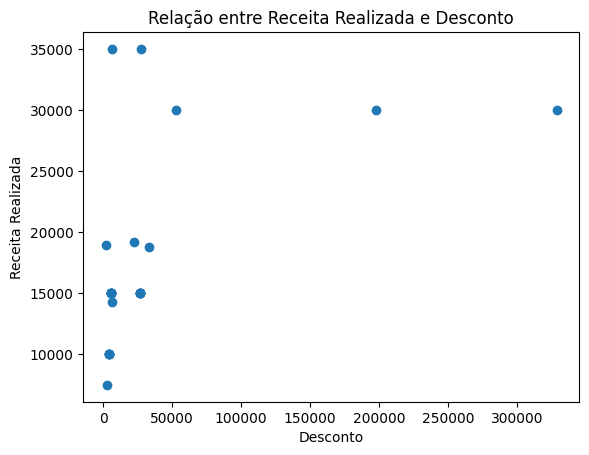

In [58]:
import matplotlib.pyplot as plt

plt.scatter(df_descontos["desconto"], df_descontos["receita_realizada"])
plt.xlabel("Desconto")
plt.ylabel("Receita Realizada")
plt.title("Relação entre Receita Realizada e Desconto")

Pelo gráfico vimos que não existe uma relação dos descontos e a receita realizada, porém não sabemos se a proporção do desconto é a mesma ou não, vamos analisar essa questão

Text(0.5, 1.0, 'Relação entre Receita Realizada e Percentual de Desconto')

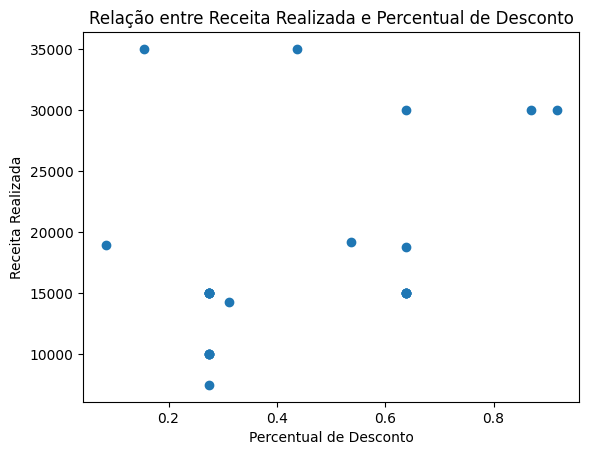

In [59]:
plt.scatter(df_descontos["percentual_desconto"], df_descontos["receita_realizada"])
plt.xlabel("Percentual de Desconto")
plt.ylabel("Receita Realizada")
plt.title("Relação entre Receita Realizada e Percentual de Desconto")

Vemos que, de fato, não há nenhuma correlação do percentual de desconto na receita realizada, podemos checar se a distribuição é mais compactada, o que significaria que a política de descontos segue aproximadamente na mesma proporção para todos concedidos com desconto.

Os pontos que se localizam na faixa direita inferior são pontos de atenção, sugerem que foi dado mais desconto e retornou pouca receita proporcional, pelo gráfico, temos poucos casos.

Text(0.5, 1.0, 'Boxplot do Percentual de Desconto')

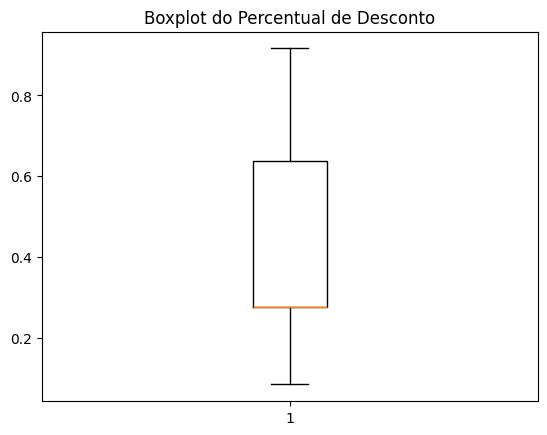

In [60]:
plt.boxplot(df_descontos["percentual_desconto"])
plt.title("Boxplot do Percentual de Desconto")

Curiosamente, pontos que poderíamos chamar de extremos, não são considerados outliers por definição, o primeiro quartil é igual à mediana, isso significa que temos muito descontos iguais nesse valor.

Text(0.5, 0, 'Percentual de Desconto')

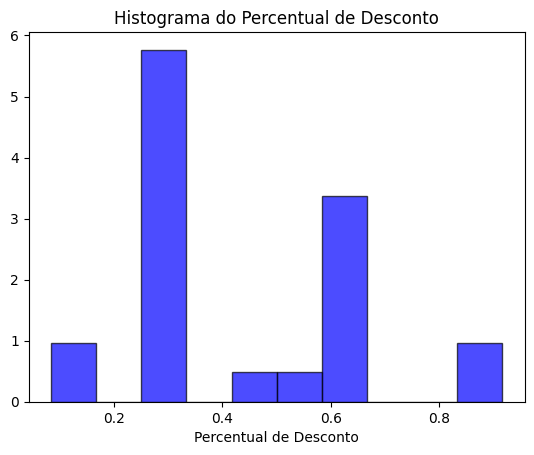

In [69]:
plt.hist(df_descontos["percentual_desconto"], bins=10, density=True, alpha=0.7, color='blue', edgecolor='black')
plt.title("Histograma do Percentual de Desconto")
plt.xlabel("Percentual de Desconto")

A análise do histograma revela que o comportamento dos descontos não segue uma distribuição contínua, mas sim um padrão de picos e vãos (gaps) bem definidos. O gráfico mostra claramente que os descontos na operação "saltam" entre patamares específicos, em vez de variar de forma fluida.

Esse tipo de comportamento sugere que, existe uma "perda de margem" por falta de flexibilidade ou por medo de negociar no meio do caminho. Se todo mundo pula de 30% para 60%, a empresa pode estar perdendo dinheiro em negociações que poderiam ter sido fechadas com 40%.

Vamos analisar médias de receita para clientes que receberam desconto e que não receberam desconto

In [62]:
df["recebeu_desconto"] = df["percentual_desconto"] > 0
df.groupby("recebeu_desconto")[["receita_realizada", "area"]].mean()

,receita_realizada,area
recebeu_desconto,,
False,20700.0,30.0
True,17746.4,75.6


Temos uma diferença de aproximadamente R$ 3.000,00 na média e 45 m2.

A política de desconto não faz sentido, para quem recebe desconto, é adquirido mais área, porém o desconto é agressivo de forma a deixar a receita menor dos clientes que adquirem menos área.

Vamos analisar agora como é essa relação para o valor de metro quadrado de fato, isso é, a receita realizada / area.

In [63]:
df.groupby("recebeu_desconto")[["preco_m2"]].mean()

,preco_m2
recebeu_desconto,
False,690.000000
True,391.912945


Quem recebe desconto recebe R$ 300,00 a menos no metro quadrado.

### O Impacto Da Comissão

Os dados indicam que a política de descontos não está alinhada com maximização de receita. Clientes que recebem desconto adquirem maior área, porém geram menor receita média e, possivelmente, menor receita por metro quadrado. Além disso, o padrão discreto de aplicação de descontos sugere ineficiência no processo de negociação, com potencial perda de margem em faixas intermediárias não exploradas.

Tudo isso pode ser explicado pelo fator de clientes comissionados, isso é o que veremos agora.

In [64]:
df.groupby(["comissionado", "recebeu_desconto"])[["preco_m2", "percentual_desconto", "receita_realizada", "area"]].mean()

preco_m2  percentual_desconto  \
comissionado recebeu_desconto                                    
0            False             690.000000             0.000000   
             True              461.208181             0.331582   
1            True              303.719008             0.559828   

                               receita_realizada       area  
comissionado recebeu_desconto                                
0            False                  20700.000000  30.000000  
             True                   18207.857143  71.071429  
1            True                   17159.090909  81.363636

Os dados evidenciam que expositores comissionados apresentam um preço médio por metro quadrado significativamente inferior (R$303 vs R$461), além de maior volume de área comercializada, porém sem geração proporcional de receita.

É importante destacar que, nesse contexto, a diferença observada não decorre de descontos no sentido tradicional. Enquanto expositores não comissionados operam com precificação baseada em metro quadrado, os comissionados seguem um modelo de remuneração baseado em mínimo garantido, no qual a receita da empresa é definida por um valor fixo inicial, independentemente do volume comercializado até determinado patamar.

Como consequência, há um desalinhamento entre o preço implícito por metro quadrado e a receita efetivamente capturada. Até que o limite de ativação da comissão seja atingido, o expositor não possui incentivo econômico para otimizar preço ou margem, priorizando o aumento de volume.

Esse modelo resulta, na prática, em uma diluição do valor por metro quadrado e indica que a estrutura atual pode estar incentivando decisões comerciais que não maximizam a rentabilidade da operação.

Clientes que pagam preço cheio, mesmo adquirindo menor área, geram maior receita média e maior valor por metro quadrado. Por outro lado, o modelo comissionado aumenta o volume vendido, mas reduz significativamente o valor capturado por área, indicando uma troca ineficiente entre volume e rentabilidade.

Enquanto o modelo comissionado ainda oferece potencial de ganho futuro, o desconto aplicado em vendas não comissionadas representa perda definitiva de receita, tornando-se o principal fator de destruição de valor na operação.

### Conclusão: Identificação do "Gargalo" de Receita e o Papel da Comissão

A análise aprofundada dos dados revela que o "vilão" do atingimento da meta não é um fator isolado, mas sim um desalinhamento na estratégia de concessão de benefícios, que se divide em dois perfis críticos de baixo desempenho:

Expositores Comissionados: Apresentam o menor preço médio por metro quadrado (R$ 303,00) e os maiores percentuais de "desconto implícito" (56%). Embora esse grupo comercialize volumes maiores de área, a receita imediata é diluída pelo modelo de mínimo garantido. Contudo, este perfil possui um valor residual positivo, uma vez que a empresa mantém participação nas vendas pós-evento, o que pode compensar o baixo valor do m² inicial.

Expositores Não-Comissionados com Desconto: Este grupo representa o ponto de maior atenção para a estratégia comercial. Com uma média de preço por m² de R$ 461,00 (bem abaixo dos R$ 690,00 de quem paga o preço cheio), esses clientes recebem descontos agressivos sem a contrapartida da comissão futura. Diferente dos comissionados, aqui o desconto concedido é receita perdida de forma definitiva, sem possibilidade de recuperação após o evento.

## A vacância de espaços impacta a receita de forma relevante?


In [65]:
query_vacancia = "SELECT * FROM expositores_atual WHERE pipeline = 'RJ_26' AND nome_fantasia = 'VACÂNCIA'"

df_vacancia = pd.read_sql(query_vacancia, engine)

df_vacancia["receita_prevista"].sum()


np.float64(952200.0)

Sabendo que faltam aproximadamente R$ 1M para meta e que a receita esperada das vacâncias está em torno de R$ 952k, quase metade do valor, podemos concluir que mesmo com 100% do evento fechado (com o preço cheio previsto das vacâncias) não bateríamos a meta.

A vacância impacta significativamente, porém não nos salvaria, devido à política previamente aplicada em pricing.

### Conclusão: A Insuficiência da Ocupação e a Destruição de Valor no Pricing

A análise dos dados revela que o desafio comercial do evento transcende a simples ocupação do espaço físico. O impacto das vacâncias é significativo, representando quase metade do gap para a meta (R$ 952k), porém, mesmo com 100% de ocupação vendida ao preço previsto hoje, a meta ainda não seria atingida. Isso demonstra que a viabilidade financeira do evento foi comprometida na origem, pela política de pricing aplicada às negociações já fechadas.

O problema central não é a existência de descontos, mas a ineficiência das concessões realizadas. Existem dois perfis críticos que "pressionam" a receita para baixo:

Clientes Comissionados: Operam com o menor preço por m² (média de R$ 303,00) e altos descontos implícitos (56%), mas mantêm um valor residual pela participação nas vendas pós-evento.

Clientes Não-Comissionados com Desconto: Representam a maior destruição de valor, com preço médio de R$ 461,00 (contra os R$ 690,00 previstos). Neste grupo, o desconto é uma perda definitiva de receita, sem qualquer contrapartida futura, diferentemente do modelo de comissão.

# Quantificação do "Vazamento" de Receita (O custo do erro)

Uma vez identificado os vilões da receita, vamos descobrir qual impacto real nessa receita perdida.

In [67]:
df_perda = df[(df["comissionado"] == 0) & (df["percentual_desconto"] > 0)]

df_perda['perda_absoluta'] = (690 - df_perda['preco_m2']) * df_perda['area']

total_perdido = df_perda['perda_absoluta'].sum()

total_realizado = df_perda["receita_realizada"].sum()
print(f"O desconto em stands fixos custou: R$ {total_perdido:,.2f}")
print(f"O valor realizado com os stands fixos foi: R$ {total_realizado:,.2f}")

O desconto em stands fixos custou: R$ 431,640.00
O valor realizado com os stands fixos foi: R$ 254,910.00


### Conclusão

Ao compararmos o potencial de receita (baseado no preço padrão de R$ 690,00/m²) com a receita efetivamente realizada, identificamos uma destruição de valor crítica:

Custo Total do Desconto (Vazamento): R$ 431.640,00

Receita Efetivamente Realizada: R$ 254.910,00

Eficiência de Captura: 37%

Para cada R$ 1,00 que entrou no caixa vindo deste segmento, a operação renunciou a R$ 1,69 em descontos irreversíveis.

A gravidade do "vazamento" fica evidente quando comparamos a perda nos stands fixos com a receita gerada pelos demais pilares do evento:

Desconto em Fixos vs. Receita Comissionada: O valor perdido em descontos (R$ 431k) é 2,3 vezes maior do que toda a receita bruta gerada pelos clientes comissionados (R$ 188k).

Impacto no Gap da Meta: Considerando que o evento possui um gap de aproximadamente R$ 1.000.000,00 para atingir a meta comercial, apenas a correção da política de descontos neste nicho teria reduzido o problema em 43%.

Os dados demonstram que o esforço para atrair grandes marcas e gerar volume via comissão foi anulado pela agressividade descontrolada nos descontos dos stands fixos. O "vazamento" identificado não é um investimento em relacionamento, mas sim uma renúncia de margem que torna o ponto de equilíbrio (break-even) do evento muito mais difícil de ser alcançado.

## Simulação de Cenários (Análise "What-if")

Nesta simulação, abandonamos o modelo de "saltos" e aplicamos uma lógica de rebaixamento por faixa. O objetivo é testar o impacto financeiro de uma política comercial que obrigue as negociações a recuarem dos picos de desconto atuais para os patamares intermediários (os vãos), onde a margem é melhor preservada.

Aplicamos os seguintes gatilhos de otimização baseados na anatomia do histograma atual:

 - Faixa 1 (Ajuste no Pico Principal): Descontos entre 25% e 30% são otimizados para 20%.

 - Faixa 2 (Ajuste no Pico Agressivo): Descontos entre 40% e 60% são otimizados para 35% (ou 40%, dependendo da agressividade desejada, mas seguindo sua lógica de "descer o degrau").

 - Faixa 3 (Ajuste no Pico Extremo): Descontos entre 70% e 90% são otimizados para 65%.


💰 Ganho total com otimização: R$ 116,450.00

📊 Venda total necessária por comissionado:
         MG     P  threshold  venda_total_necessaria
1   30000.0  0.05   600000.0               2929000.0
2   10000.0  0.10   100000.0               1264500.0
3   30000.0  0.10   300000.0               1464500.0
10  10000.0  0.10   100000.0               1264500.0
20  15000.0  0.10   150000.0               1314500.0
28  15000.0  0.08   187500.0               1643125.0
29  18750.0  0.10   187500.0               1352000.0
33  15000.0  0.10   150000.0               1314500.0
36  15000.0  0.10   150000.0               1314500.0
39  15000.0  0.10   150000.0               1314500.0
40  15000.0  0.10   150000.0               1314500.0


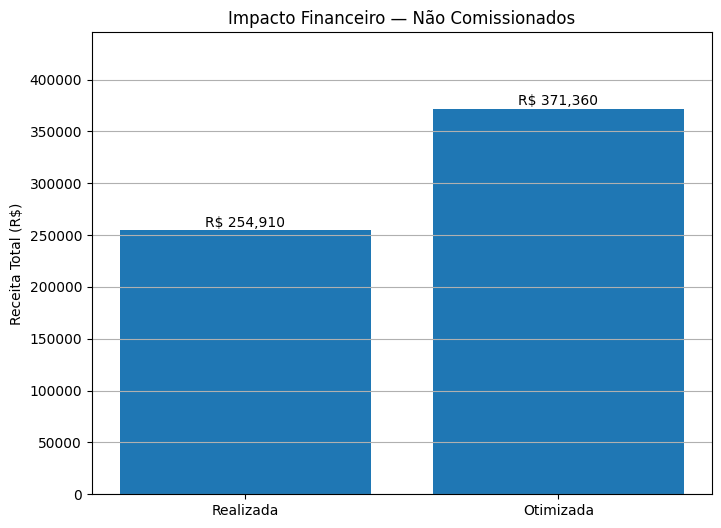

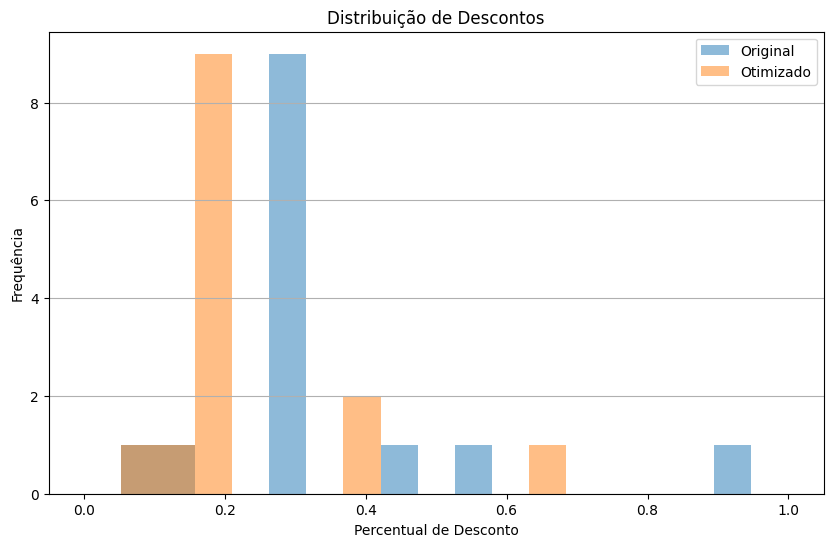

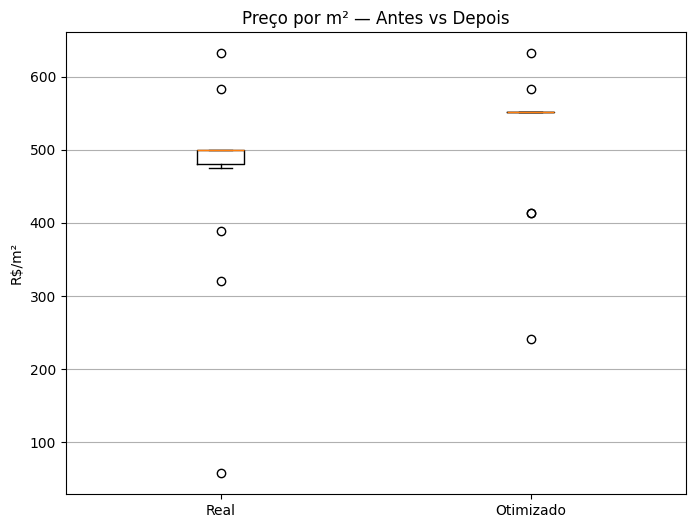

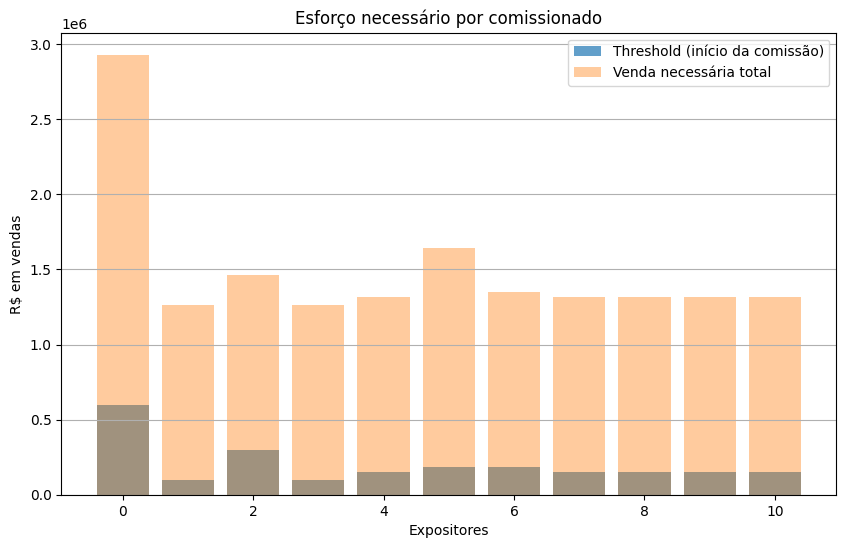


📌 RESUMO FINAL
Receita atual (não comissionados): R$ 254,910.00
Receita otimizada: R$ 371,360.00
Ganho potencial: R$ 116,450.00
Venda média necessária (comissionados): R$ 1,499,102.27


In [78]:
# =========================
# 1. FILTRAR DADOS
# =========================
df_perda = df[(df["comissionado"] == 0) & (df["percentual_desconto"] > 0)].copy()
df_comissao = df[df["comissionado"] == 1].copy()

# =========================
# 2. FUNÇÃO DE OTIMIZAÇÃO
# =========================
def aplicar_otimizacao(row):
    d = row['percentual_desconto']
    area = row['area']
    preco_cheio = 690

    if 0.25 <= d < 0.35:
        novo_d = 0.20
    elif 0.40 <= d < 0.65:
        novo_d = 0.40
    elif 0.70 <= d <= 0.95:
        novo_d = 0.65
    else:
        return row['receita_realizada'], d

    receita = area * preco_cheio * (1 - novo_d)
    return receita, novo_d

# Aplicar otimização
df_perda[['receita_otimizada', 'novo_d']] = df_perda.apply(
    aplicar_otimizacao, axis=1, result_type='expand'
)

# =========================
# 3. GANHO TOTAL
# =========================
receita_real = df_perda["receita_realizada"].sum()
receita_otimizada = df_perda["receita_otimizada"].sum()
ganho_total = receita_otimizada - receita_real

print(f"\n💰 Ganho total com otimização: R$ {ganho_total:,.2f}")

# =========================
# 4. MODELO COMISSIONADO (CORRETO)
# =========================
# MG = receita_realizada
# P = percentual_comissao

df_comissao["MG"] = df_comissao["receita_realizada"]
df_comissao["P"] = df_comissao["percentual_comissao"]

# Threshold: quando começa a gerar receita adicional
df_comissao["threshold"] = df_comissao["MG"] / df_comissao["P"]

# =========================
# 5. QUANTO PRECISA VENDER PARA GERAR O GANHO?
# =========================
Y = ganho_total

# Venda necessária para gerar Y adicional
df_comissao["venda_para_Y"] = Y / df_comissao["P"]

# Venda total necessária (threshold + extra)
df_comissao["venda_total_necessaria"] = (
    df_comissao["threshold"] + df_comissao["venda_para_Y"]
)

print("\n📊 Venda total necessária por comissionado:")
print(df_comissao[["MG", "P", "threshold", "venda_total_necessaria"]])

# =========================
# 6. GRÁFICO 1 — RECEITA REAL vs OTIMIZADA
# =========================
plt.figure(figsize=(8, 6))

labels = ['Realizada', 'Otimizada']
valores = [receita_real, receita_otimizada]

bars = plt.bar(labels, valores)

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval * 1.01,
             f'R$ {yval:,.0f}', ha='center')

plt.title('Impacto Financeiro — Não Comissionados')
plt.ylabel('Receita Total (R$)')
plt.ylim(0, max(valores) * 1.2)
plt.grid(axis='y')
plt.show()

# =========================
# 7. GRÁFICO 2 — DISTRIBUIÇÃO DE DESCONTOS
# =========================
plt.figure(figsize=(10, 6))

bins = np.linspace(0, 1, 20)

plt.hist(df_perda['percentual_desconto'], bins=bins, alpha=0.5, label='Original')
plt.hist(df_perda['novo_d'], bins=bins, alpha=0.5, label='Otimizado')

plt.title('Distribuição de Descontos')
plt.xlabel('Percentual de Desconto')
plt.ylabel('Frequência')
plt.legend()
plt.grid(axis='y')
plt.show()

# =========================
# 8. GRÁFICO 3 — PREÇO POR M²
# =========================
plt.figure(figsize=(8, 6))

preco_real = df_perda["receita_realizada"] / df_perda["area"]
preco_otimizado = df_perda["receita_otimizada"] / df_perda["area"]

plt.boxplot([preco_real, preco_otimizado])
plt.xticks([1, 2], ['Real', 'Otimizado'])

plt.title('Preço por m² — Antes vs Depois')
plt.ylabel('R$/m²')
plt.grid(axis='y')
plt.show()

# =========================
# 9. GRÁFICO 4 — THRESHOLD vs VENDA NECESSÁRIA
# =========================
plt.figure(figsize=(10, 6))

x = np.arange(len(df_comissao))

plt.bar(x, df_comissao["threshold"], label="Threshold (início da comissão)", alpha=0.7)
plt.bar(x, df_comissao["venda_total_necessaria"], bottom=0, alpha=0.4, label="Venda necessária total")

plt.title("Esforço necessário por comissionado")
plt.ylabel("R$ em vendas")
plt.xlabel("Expositores")
plt.legend()
plt.grid(axis='y')
plt.show()

# =========================
# 10. RESUMO FINAL
# =========================
print("\n📌 RESUMO FINAL")
print(f"Receita atual (não comissionados): R$ {receita_real:,.2f}")
print(f"Receita otimizada: R$ {receita_otimizada:,.2f}")
print(f"Ganho potencial: R$ {ganho_total:,.2f}")
print(f"Venda média necessária (comissionados): R$ {df_comissao['venda_total_necessaria'].mean():,.2f}")

### Resultado da Simulação

Ao reajustarmos apenas esses grupos críticos de stands não-comissionados (os "vilões" da margem), o impacto financeiro é direto e significativo:

Recuperação Estimada: R$ 116.450,00.

Impacto no Gap: Essa ação sozinha cobriria aproximadamente 11,6% do buraco de R$ 1M da meta comercial.

É importante destacar que esse montante é recuperado sem a necessidade de captar um único novo cliente, tratando puramente a eficiência das negociações que já ocorreram.

O gráfico comparativo entre a distribuição original e a otimizada prova que o problema central não é a existência do desconto, mas sim o fenômeno da ancoragem. Pela ausência de uma política de faixas intermediárias clara, o vendedor tende a "pular" diretamente para o teto da alçada permitida (os picos de 60% e 85%).

A estratégia de "descer o degrau" proposta nesta simulação preenche os vãos do histograma, transformando a "escada" de descontos em uma ferramenta ativa de preservação de margem. Ocupar os vales da distribuição garante que a agressividade comercial necessária para fechar contratos não resulte em uma renúncia de receita desproporcional.

Comparação com o Modelo Comissionado

Para contextualizar a magnitude desse ganho, foi realizada uma simulação paralela considerando o modelo comissionado. Nesse cenário, buscou-se responder: quanto os expositores comissionados precisariam vender para gerar o mesmo impacto financeiro de R$ 116.450,00?

Os resultados indicam que seria necessário que cada expositor comissionado atingisse, em média, aproximadamente R$ 1,5 milhão em vendas totais, valor significativamente superior ao patamar mínimo (threshold) exigido para início da participação da empresa nas receitas.

Esse resultado evidencia dois pontos críticos:

O modelo comissionado ainda não está gerando valor adicional, pois os expositores sequer atingiram o threshold necessário.
Mesmo considerando o cenário otimista de superação desse patamar, o volume de vendas exigido para igualar o ganho obtido via otimização de descontos é extremamente elevado e potencialmente inviável no contexto atual.
Conclusão Estratégica

A comparação entre os cenários demonstra que:

A otimização da política de descontos gera impacto imediato, direto e controlável na receita;
Já o modelo comissionado depende de um crescimento expressivo e incerto de vendas para produzir o mesmo efeito — apenas para empatar, sem gerar ganho adicional.

Dessa forma, os dados indicam que a principal alavanca de recuperação de receita no curto prazo não está na expansão comercial, mas sim na correção de ineficiências no processo de precificação já existente.

Em outras palavras, o problema não está apenas em vender mais, mas em vender melhor.

# Resultado e Conclusão

Este estudo demonstra que o principal desafio comercial do evento RJ 2026 não está na demanda ou na ocupação, mas na erosão significativa de valor ao longo do processo de negociação. Mesmo em um cenário de 100% de ocupação, a meta não seria atingida, evidenciando que o gap de aproximadamente R$ 1 milhão é consequência direta de ineficiências na política de pricing aplicada.

A análise identificou um ponto crítico de perda concentrado nos expositores não comissionados com desconto, responsáveis por um vazamento de R$ 431.640,00 em receita potencial. Nesse segmento, a empresa capturou apenas 37% do valor possível, abrindo mão de R$ 1,69 em descontos para cada R$ 1,00 faturado — caracterizando uma perda definitiva, sem possibilidade de recuperação futura.

Adicionalmente, foi observado o fenômeno de Ancoragem Binária, no qual a ausência de faixas intermediárias leva os vendedores a concentrarem negociações em extremos (como 60% e 85% de desconto), criando uma estrutura ineficiente que sacrifica margem de forma desnecessária.

Para mitigar esse problema, foi simulada uma estratégia de Ocupação de Vãos, baseada na redução desses picos para níveis intermediários mais eficientes. O resultado indica uma recuperação imediata de R$ 116.450,00, equivalente a 11,6% do gap total, sem necessidade de aquisição de novos clientes — apenas com melhoria na qualidade das negociações existentes.

Quando comparado ao modelo comissionado, o ganho obtido via otimização de descontos se mostra significativamente mais eficiente. Para gerar o mesmo impacto de R$ 116 mil, seria necessário que cada expositor comissionado atingisse, em média, aproximadamente R$ 1,5 milhão em vendas totais, valor substancialmente superior ao threshold de ativação da comissão. Isso evidencia que a dependência de crescimento de vendas como estratégia de compensação é altamente custosa e incerta frente a ajustes diretos de pricing.

A análise também introduz o conceito de Ponto de Indiferença, demonstrando que o modelo comissionado só se torna vantajoso acima de determinados níveis de faturamento. Abaixo desse patamar, a empresa maximiza sua rentabilidade ao manter o cliente em um modelo fixo com política de desconto controlada.

🚀 Plano de Ação

Com base nesses achados, recomenda-se a implementação imediata das seguintes medidas:

1. Controle de Descontos (Curto Prazo):

Estabelecer descontos contínuos ao invés de descontos altos pontuais não comissionados
Criar uma escada de alçada:
até 20% de desconto
Monitorar continuamente a distribuição de descontos para eliminar picos extremos

2. Padronização do Processo Comercial:

Implementar faixas intermediárias obrigatórias de negociação
Registrar justificativas para concessão de descontos

3. Otimização do Modelo Comercial:

Aplicar o Ponto de Indiferença para decisão entre modelo fixo e comissionado
Direcionar clientes de alto potencial para comissão
Manter clientes de baixo volume em modelo fixo otimizado

4. Ajustes Estruturais:

Revisar o preço base dos stands (reduzir dependência de desconto)
Treinar o time comercial para negociação orientada a valor
Adotar receita por m² como principal métrica de performance
🏁 Conclusão

Os resultados evidenciam que a principal alavanca de recuperação de receita não está em vender mais, mas em corrigir como se vende. A otimização da política de descontos representa uma oportunidade de ganho imediato e controlável, enquanto o modelo comissionado depende de volumes elevados e incertos para gerar impacto equivalente.

Dessa forma, a sustentabilidade financeira do evento passa por uma mudança de abordagem: substituir a lógica de maximização de volume pela maximização de valor capturado em cada negociação.